In [25]:
import refinitiv.data as rd
import pandas as pd
import numpy as np
import warnings
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

rd.open_session()

<refinitiv.data.session.Definition object at 0x169924620 {name='workspace'}>

## 1. Data Fetch
STOXX Europe 600 (equity), VSTOXX (implied vol), German 2Y & 10Y yields (term spread), iTraxx Europe 5Y (credit spread)

In [26]:
# Equity index and implied volatility
df_equity = rd.get_history(
    universe=['.STOXX', '.V2TX'],
    fields=["TRDPRC_1"],
    start="2010-01-01",
    end="2026-03-05",
    interval="daily"
)

# German government bond yields
df_yields = rd.get_history(
    universe=['DE2YT=RR', 'DE10YT=RR'],
    fields=["MID_YLD_1"],
    start="2010-01-01",
    end="2026-03-05",
    interval="daily"
)

# # iTraxx Europe 5Y credit spread (requires premium license — TODO: find alternative)
# df_credit = rd.get_history(
#     universe=['ITEEU5Y=MP'],
#     start="2010-01-01",
#     end="2026-03-05",
#     interval="daily"
# )

print("Equity shape:", df_equity.shape)
print("Yields shape:", df_yields.shape)
# print("Credit shape:", df_credit.shape)
print("\nEquity date range:", df_equity.index.min(), "—", df_equity.index.max())
print("Yields date range:", df_yields.index.min(), "—", df_yields.index.max())
# print("Credit date range:", df_credit.index.min(), "—", df_credit.index.max())

Equity shape: (4153, 2)
Yields shape: (4129, 2)

Equity date range: 2010-01-04 00:00:00 — 2026-03-05 00:00:00
Yields date range: 2010-01-04 00:00:00 — 2026-03-05 00:00:00


## 2. Build HMM Feature Matrix
3 observable features: STOXX log return, VSTOXX level, term spread (10Y−2Y)
<!-- TODO: add credit spread (iTraxx) when access is available -->

In [27]:
hmm_df = pd.DataFrame(index=df_equity.index)

# STOXX 600 log return
stoxx_price = df_equity['.STOXX'].astype(float)
hmm_df['stoxx_return'] = np.log(stoxx_price / stoxx_price.shift(1))

# VSTOXX implied volatility
hmm_df['vstoxx'] = df_equity['.V2TX'].astype(float)

# Term spread: 10Y − 2Y German govt yield
hmm_df['term_spread'] = (
    df_yields['DE10YT=RR'].astype(float)
    - df_yields['DE2YT=RR'].astype(float)
)

# # Credit spread: iTraxx Europe 5Y (TODO: uncomment when access available)
# hmm_df['credit_spread'] = df_credit['ITEEU5Y=MP'].astype(float)

features = ['stoxx_return', 'vstoxx', 'term_spread']
hmm_df = hmm_df[features].dropna()

print(f"HMM feature matrix: {hmm_df.shape[0]} daily observations")
print(f"Date range: {hmm_df.index.min()} — {hmm_df.index.max()}")
print(f"\nMissing values:\n{hmm_df.isna().sum()}")
print(f"\n{hmm_df.describe()}")

HMM feature matrix: 4114 daily observations
Date range: 2010-01-05 00:00:00 — 2026-03-05 00:00:00

Missing values:
stoxx_return    0
vstoxx          0
term_spread     0
dtype: int64

       stoxx_return       vstoxx  term_spread
count   4114.000000  4114.000000  4114.000000
mean       0.000210    21.257330     0.801943
std        0.010267     7.293917     0.663325
min       -0.121915    10.678300    -0.875500
25%       -0.004463    16.382925     0.356125
50%        0.000649    19.750750     0.782500
75%        0.005598    24.134975     1.339875
max        0.080704    85.620600     2.418500


## 3. Fit 3-State Gaussian HMM
Standardize features before fitting. States are latent — we label them after fitting based on mean STOXX return per state.

In [28]:
# Standardize features (HMM is sensitive to scale differences)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hmm_df[features].values)

# Fit 3-state Gaussian HMM
model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=500,
    random_state=42,
    tol=1e-4
)
model.fit(X_scaled)

# Predict hidden states
hmm_df['raw_state'] = model.predict(X_scaled)

print(f"Model converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(X_scaled):.2f}")
print(f"\nState distribution:\n{hmm_df['raw_state'].value_counts().sort_index()}")
print(f"\nTransition matrix:\n{np.round(model.transmat_, 3)}")

Model converged: True
Log-likelihood: -12859.27

State distribution:
raw_state
0    1502
1     862
2    1750
Name: count, dtype: int64

Transition matrix:
[[0.952 0.022 0.026]
 [0.04  0.96  0.   ]
 [0.021 0.002 0.977]]


## 4. Label Regimes
Sort states by mean STOXX return: highest = Bull (0), lowest = Bear (1), middle = Transition (2)

In [29]:
# Mean STOXX return per raw state
state_means = hmm_df.groupby('raw_state')['stoxx_return'].mean().sort_values(ascending=False)
print("Mean daily STOXX return per raw state:")
print(state_means)

# Map: highest mean → Bull (0), lowest → Bear (1), middle → Transition (2)
sorted_states = state_means.index.tolist()
regime_map = {
    sorted_states[0]: 0,  # Bull
    sorted_states[2]: 1,  # Bear
    sorted_states[1]: 2,  # Transition
}
regime_labels = {0: 'Bull', 1: 'Bear', 2: 'Transition'}

hmm_df['HMM_Regime'] = hmm_df['raw_state'].map(regime_map)

print(f"\nRegime mapping (raw_state → regime): {regime_map}")
print(f"\nRegime distribution:")
for regime_id, label in regime_labels.items():
    count = (hmm_df['HMM_Regime'] == regime_id).sum()
    pct = count / len(hmm_df) * 100
    mean_ret = hmm_df.loc[hmm_df['HMM_Regime'] == regime_id, 'stoxx_return'].mean()
    mean_vol = hmm_df.loc[hmm_df['HMM_Regime'] == regime_id, 'vstoxx'].mean()
    print(f"  {label} ({regime_id}): {count} days ({pct:.1f}%), mean return={mean_ret:.5f}, mean VSTOXX={mean_vol:.1f}")

Mean daily STOXX return per raw state:
raw_state
2    0.000686
0    0.000260
1   -0.000845
Name: stoxx_return, dtype: float64

Regime mapping (raw_state → regime): {2: 0, 1: 1, 0: 2}

Regime distribution:
  Bull (0): 1750 days (42.5%), mean return=0.00069, mean VSTOXX=15.7
  Bear (1): 862 days (21.0%), mean return=-0.00085, mean VSTOXX=32.1
  Transition (2): 1502 days (36.5%), mean return=0.00026, mean VSTOXX=21.5


## 5. Visualization

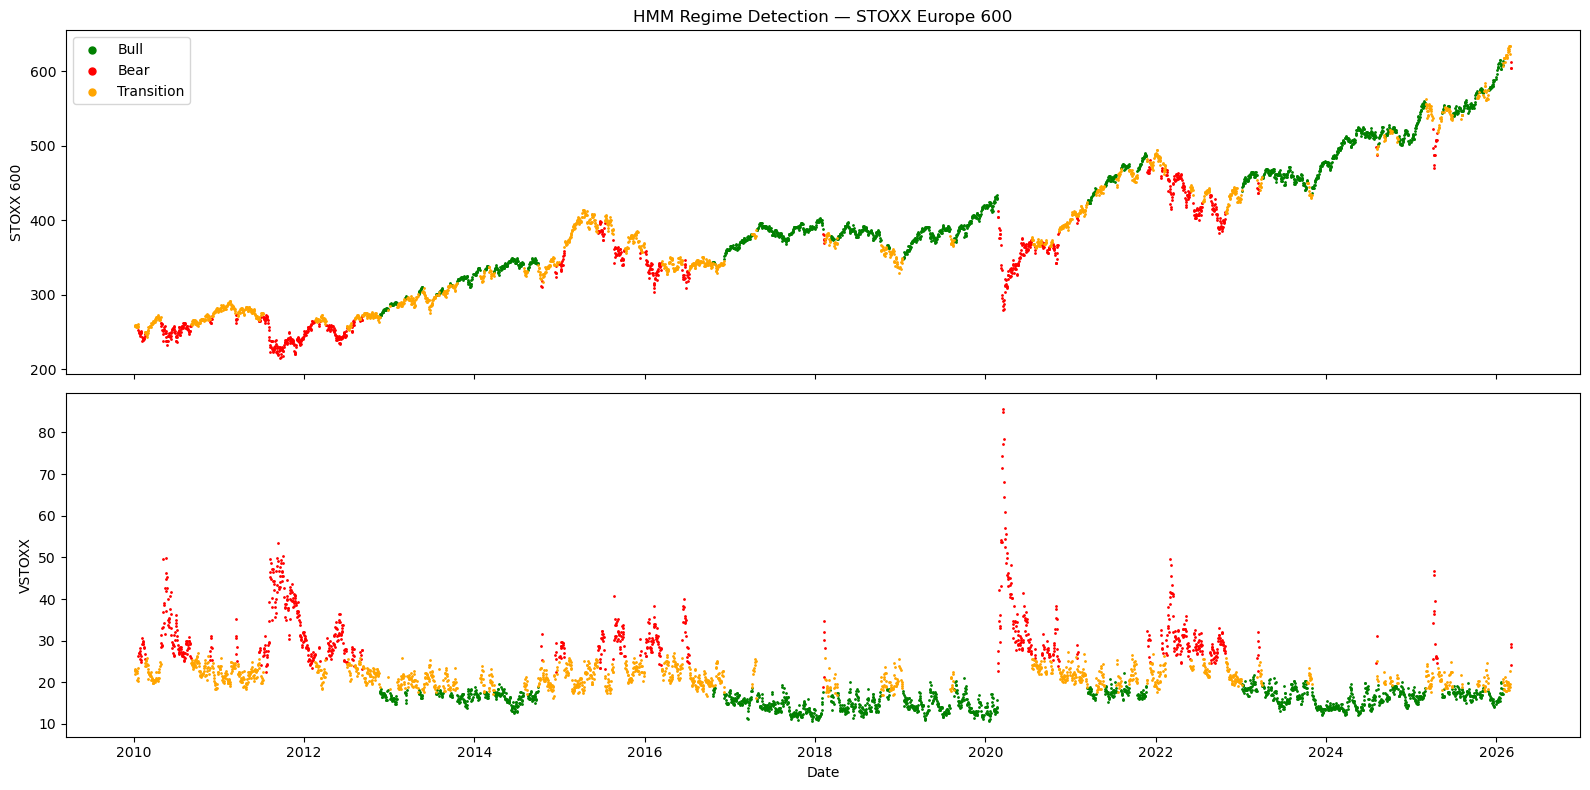

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

colors = {0: 'green', 1: 'red', 2: 'orange'}
labels = {0: 'Bull', 1: 'Bear', 2: 'Transition'}

# Plot 1: STOXX 600 price with regime coloring
ax1 = axes[0]
stoxx_plot = stoxx_price.reindex(hmm_df.index)
for regime_id, color in colors.items():
    mask = hmm_df['HMM_Regime'] == regime_id
    ax1.scatter(hmm_df.index[mask], stoxx_plot[mask], c=color, s=1, label=labels[regime_id])
ax1.set_ylabel('STOXX 600')
ax1.legend(loc='upper left', markerscale=5)
ax1.set_title('HMM Regime Detection — STOXX Europe 600')

# Plot 2: VSTOXX with regime coloring
ax2 = axes[1]
for regime_id, color in colors.items():
    mask = hmm_df['HMM_Regime'] == regime_id
    ax2.scatter(hmm_df.index[mask], hmm_df.loc[mask, 'vstoxx'], c=color, s=1)
ax2.set_ylabel('VSTOXX')
ax2.set_xlabel('Date')

# # Plot 3: Credit spread (TODO: uncomment when available)
# ax3 = axes[2]
# for regime_id, color in colors.items():
#     mask = hmm_df['HMM_Regime'] == regime_id
#     ax3.scatter(hmm_df.index[mask], hmm_df.loc[mask, 'credit_spread'], c=color, s=1)
# ax3.set_ylabel('iTraxx Europe 5Y (bps)')
# ax3.set_xlabel('Date')

plt.tight_layout()
plt.show()

## 6. Aggregate to Monthly & Save
Take the regime of the last trading day of each month. This is the regime label used as a feature in the ML models.

In [31]:
# Last trading day of each month
monthly_regime = hmm_df[['HMM_Regime']].resample('ME').last()
monthly_regime.index.name = 'Date'

print(f"Monthly regime labels: {len(monthly_regime)} months")
print(f"Date range: {monthly_regime.index.min().strftime('%Y-%m')} — {monthly_regime.index.max().strftime('%Y-%m')}")
print(f"\nMonthly regime distribution:")
print(monthly_regime['HMM_Regime'].value_counts().rename({0: 'Bull (0)', 1: 'Bear (1)', 2: 'Transition (2)'}).sort_index())

monthly_regime.head(10)

Monthly regime labels: 195 months
Date range: 2010-01 — 2026-03

Monthly regime distribution:
HMM_Regime
Bear (1)          45
Bull (0)          80
Transition (2)    70
Name: count, dtype: int64


,HMM_Regime
Date,
2010-01-31,1
2010-02-28,2
2010-03-31,2
2010-04-30,1
2010-05-31,1
2010-06-30,1
2010-07-31,1
2010-08-31,1
2010-09-30,2


In [32]:
# Save daily HMM results (for analysis)
hmm_df[['HMM_Regime']].to_csv('../../data/01_raw/hmm_regimes_daily.csv')

# Save monthly regime labels (for ML pipeline)
monthly_regime.to_csv('../../data/01_raw/hmm_regimes_monthly.csv')

print("Saved: data/01_raw/hmm_regimes_daily.csv")
print("Saved: data/01_raw/hmm_regimes_monthly.csv")

Saved: data/01_raw/hmm_regimes_daily.csv
Saved: data/01_raw/hmm_regimes_monthly.csv
